# Advanced Black–Litterman variants

The base `BlackLittermanPrior` ([previous page](05_Black_Litterman.md)) works entirely
in **asset space**: views are statements about individual assets or asset groups. But views
are often more naturally expressed about **factors** — "momentum will earn a premium",
"quality minus low-volatility will be negative" — and sometimes you hold asset *and* factor
views at once. `PortfolioOptimisers` ships three variants of the model for exactly these cases:

  - `BayesianBlackLittermanPrior` — the Bayesian formulation that sits on top of a
    `FactorPrior`. Views are expressed on the factors, and the factor structure
    propagates the posterior back to the assets.
  - `FactorBlackLittermanPrior` — expresses views directly on **factor premia** and
    pushes them to the assets through a factor regression. The `rsd` flag controls whether
    idiosyncratic residual variance is retained, and `l` is the risk-aversion of the implied
    factor equilibrium.
  - `AugmentedBlackLittermanPrior` — carries **both** asset views (`a_views`) and
    factor views (`f_views`) simultaneously, each with its own asset set and confidence.

All three return an asset-space posterior `(mu, sigma)` you can feed to any optimiser, exactly
like the base model.

> **When to reach for this**
>
> Reach for these when your conviction is about factors rather than (or in addition to)
> individual names: a macro view on momentum or value, a quality-vs-low-vol spread, or a
> desk that wants to combine a stock-level call with a factor-level call in one coherent
> posterior. If all your views are plain asset statements, the base
> `BlackLittermanPrior` is simpler and enough.

> **Factor data required**
>
> These variants need factor returns, so the `ReturnsResult` must be built with a
> factor block via `prices_to_returns(X, F)`. Factor views and factor sets refer to the
> factor names in `rd.nf`.

In [1]:
using PortfolioOptimisers, PrettyTables, DataFrames

mmtfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v * 100, digits = 4)) %" : v
    end
end;
resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v * 100, digits = 3)) %" : v
    end
end;

## 1. Data, sets, and the equilibrium baseline

We load the S&P 500 slice **with** its factor block, then declare two `AssetSets`: one over the
assets (with a couple of groups, for the augmented asset views) and one over the factor names.
The `EquilibriumExpectedReturns` prior is the neutral anchor every Black–Litterman
posterior tilts away from.

In [2]:
using CSV, TimeSeries

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
F = TimeArray(CSV.File(joinpath(@__DIR__, "..", "Factors.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X, F)

asset_sets = AssetSets(;
                       dict = Dict("nx" => rd.nx, "tech" => ["AAPL", "AMD", "MSFT"],
                                   "energy" => ["CVX"]))
factor_sets = AssetSets(; dict = Dict("nx" => rd.nf))
tau = 1 / size(rd.X, 1)

pr_eq = prior(EmpiricalPrior(; me = EquilibriumExpectedReturns()), rd)

LowOrderPrior
        X ┼ 252×20 Matrix{Float64}
       mu ┼ 20-element Vector{Float64}
    sigma ┼ 20×20 Matrix{Float64}
     chol ┼ nothing
        w ┼ nothing
      ens ┼ nothing
      kld ┼ nothing
       ow ┼ nothing
       rr ┼ nothing
     f_mu ┼ nothing
  f_sigma ┼ nothing
      f_w ┴ nothing


The factors available in this dataset:

In [3]:
pretty_table(DataFrame(; factor = rd.nf); title = "Factor names (rd.nf)")

Factor names (rd.nf)
┌────────┐
│ factor │
│ String │
├────────┤
│   MTUM │
│   QUAL │
│   SIZE │
│   USMV │
│   VLUE │
└────────┘


## 2. Bayesian Black–Litterman: factor views on a factor prior

`BayesianBlackLittermanPrior` takes a `FactorPrior` as its base estimator and
accepts views written in **factor space** (so its `sets` are the factor sets). It is the
Bayesian formulation: the factor prior supplies the structure, the views update the factor
means, and the result is mapped back to an asset-space posterior.

Our factor views: momentum earns 5 bps/day, and quality underperforms low-volatility by 3
bps/day.

In [4]:
factor_views = LinearConstraintEstimator(;
                                         val = ["MTUM == 0.0005", "QUAL - USMV == -0.0003"])

pr_bayes = prior(BayesianBlackLittermanPrior(; pe = FactorPrior(; pe = EmpiricalPrior()),
                                             sets = factor_sets, tau = tau,
                                             views = factor_views), rd)

LowOrderPrior
        X ┼ 252×20 Matrix{Float64}
       mu ┼ 20-element Vector{Float64}
    sigma ┼ 20×20 Matrix{Float64}
     chol ┼ nothing
        w ┼ nothing
      ens ┼ nothing
      kld ┼ nothing
       ow ┼ nothing
       rr ┼ Regression
          │   M ┼ 20×5 SubArray{Float64, 2, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, UnitRange{Int64}}, true}
          │   L ┼ 20×5 SubArray{Float64, 2, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, UnitRange{Int64}}, true}
          │   b ┴ 20-element SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}
     f_mu ┼ Vector{Float64}: [-0.0007221367902182355, -0.0008384535501032073, -0.0006253517821839465, -0.0003358529620217417, -0.000559091885073412]
  f_sigma ┼ 5×5 Matrix{Float64}
      f_w ┴ nothing


## 3. Factor Black–Litterman: views on factor premia

`FactorBlackLittermanPrior` also takes factor views, but propagates them to the assets
through the factor regression rather than a factor prior. Two knobs matter:

  - `rsd` — keep the idiosyncratic **residual** variance (`true`) or drop it (`false`), i.e.
    whether the posterior covariance is the full asset covariance or only its factor-explained
    part.
  - `l` — the risk-aversion of the implied factor equilibrium.

We build both `rsd` settings and a higher-risk-aversion variant to show each knob moves the
posterior.

In [5]:
pr_fbl_rsd = prior(FactorBlackLittermanPrior(; pe = EmpiricalPrior(), rsd = true,
                                             sets = factor_sets, tau = tau,
                                             views = factor_views), rd)
pr_fbl_nors = prior(FactorBlackLittermanPrior(; pe = EmpiricalPrior(), rsd = false,
                                              sets = factor_sets, tau = tau,
                                              views = factor_views), rd)
pr_fbl_l = prior(FactorBlackLittermanPrior(; pe = EmpiricalPrior(), rsd = true, l = 5.0,
                                           sets = factor_sets, tau = tau,
                                           views = factor_views), rd)

i_aapl = findfirst(==("AAPL"), rd.nx)
pretty_table(DataFrame(; quantity = ["AAPL posterior mean", "AAPL posterior variance"],
                       rsd_true = [pr_fbl_rsd.mu[i_aapl], pr_fbl_rsd.sigma[i_aapl, i_aapl]],
                       rsd_false = [pr_fbl_nors.mu[i_aapl],
                                    pr_fbl_nors.sigma[i_aapl, i_aapl]]);
             formatters = [mmtfmt], title = "Factor BL: residual variance on vs off")

      Factor BL: residual variance on vs off
┌─────────────────────────┬──────────┬───────────┐
│                quantity │ rsd_true │ rsd_false │
│                  String │  Float64 │   Float64 │
├─────────────────────────┼──────────┼───────────┤
│     AAPL posterior mean │ -0.044 % │  -0.044 % │
│ AAPL posterior variance │ 0.0501 % │  0.0384 % │
└─────────────────────────┴──────────┴───────────┘


Dropping the residual variance (`rsd = false`) leaves only the factor-explained part of the
covariance, so the posterior variance is smaller — the model trusts the factor structure to
explain all risk.

## 4. Augmented Black–Litterman: asset and factor views together

`AugmentedBlackLittermanPrior` is the most general: it takes asset views (`a_views`,
with asset sets) **and** factor views (`f_views`, with factor sets) in the same posterior. Use
it when you have a stock-specific call and a factor call you do not want to choose between.

In [6]:
asset_views = LinearConstraintEstimator(; val = ["AAPL == 0.0008", "tech == 0.0006"])

pr_aug = prior(AugmentedBlackLittermanPrior(; a_sets = asset_sets, f_sets = factor_sets,
                                            tau = tau, a_views = asset_views,
                                            f_views = factor_views), rd)

LowOrderPrior
        X ┼ 252×20 Matrix{Float64}
       mu ┼ 20-element Vector{Float64}
    sigma ┼ 20×20 Matrix{Float64}
     chol ┼ nothing
        w ┼ nothing
      ens ┼ nothing
      kld ┼ nothing
       ow ┼ nothing
       rr ┼ Regression
          │   M ┼ 20×5 SubArray{Float64, 2, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, UnitRange{Int64}}, true}
          │   L ┼ 20×5 SubArray{Float64, 2, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, UnitRange{Int64}}, true}
          │   b ┴ 20-element SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}
     f_mu ┼ Vector{Float64}: [-0.0007221367902182355, -0.0008384535501032073, -0.0006253517821839465, -0.0003358529620217417, -0.000559091885073412]
  f_sigma ┼ 5×5 Matrix{Float64}
      f_w ┴ nothing


## 5. Comparing the posteriors

Each variant produces a different asset-space posterior mean. Below we line them up against the
equilibrium anchor for the first few assets — the factor views move the whole cross-section,
and the augmented model additionally tilts the assets named in its asset views.

        Posterior expected returns (first 8 assets)
┌────────┬─────────────┬───────────┬───────────┬───────────┐
│ Assets │ Equilibrium │  Bayesian │    Factor │ Augmented │
│ String │     Float64 │   Float64 │   Float64 │   Float64 │
├────────┼─────────────┼───────────┼───────────┼───────────┤
│   AAPL │    0.0231 % │  0.0036 % │  -0.044 % │  0.0217 % │
│    AMD │    0.0362 % │ -0.1036 % │ -0.1656 % │ -0.1488 % │
│    BAC │    0.0191 % │  0.0005 % │ -0.0392 % │ -0.0373 % │
│    BBY │    0.0239 % │  0.0659 % │  0.0316 % │  0.1339 % │
│    CVX │    0.0144 % │  0.2523 % │  0.2295 % │  0.4814 % │
│     GE │    0.0194 % │  0.0642 % │  0.0212 % │  0.0807 % │
│     HD │    0.0178 % │  0.0126 % │ -0.0229 % │   0.001 % │
│    JNJ │    0.0075 % │  0.0701 % │  0.0456 % │  0.0907 % │
└────────┴─────────────┴───────────┴───────────┴───────────┘


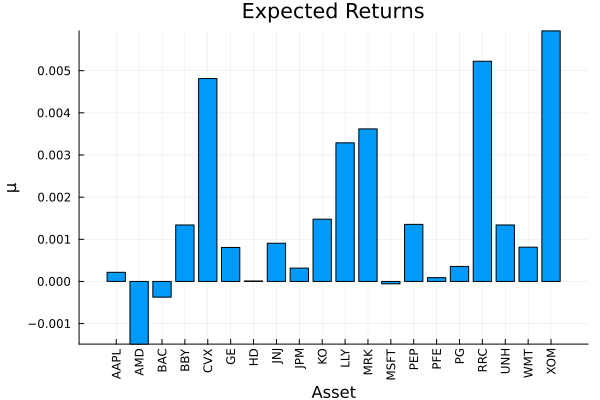

In [7]:
cmp = DataFrame(; Assets = rd.nx, Equilibrium = pr_eq.mu, Bayesian = pr_bayes.mu,
                Factor = pr_fbl_rsd.mu, Augmented = pr_aug.mu)
pretty_table(first(cmp, 8); formatters = [mmtfmt],
             title = "Posterior expected returns (first 8 assets)")

using StatsPlots, GraphRecipes
plot_mu(pr_aug, rd.nx)

## 6. From views to portfolios

The payoff is the same as for the base model: each posterior reshapes the optimal portfolio.
We solve a maximum-ratio portfolio under the equilibrium prior and under each variant, then
compare the compositions.

              Maximum-ratio weights by prior
┌────────┬─────────────┬──────────┬──────────┬───────────┐
│ assets │ Equilibrium │ Bayesian │   Factor │ Augmented │
│    Any │         Any │      Any │      Any │       Any │
├────────┼─────────────┼──────────┼──────────┼───────────┤
│   AAPL │       0.0 % │    0.0 % │    0.0 % │     0.0 % │
│    AMD │    78.713 % │    0.0 % │    0.0 % │     0.0 % │
│    BAC │       0.0 % │    0.0 % │    0.0 % │     0.0 % │
│    BBY │       0.0 % │    0.0 % │    0.0 % │     0.0 % │
│    CVX │       0.0 % │ 18.839 % │ 19.292 % │   0.001 % │
│     GE │       0.0 % │    0.0 % │    0.0 % │     0.0 % │
│     HD │       0.0 % │    0.0 % │    0.0 % │     0.0 % │
│    JNJ │       0.0 % │    0.0 % │    0.0 % │     0.0 % │
│    JPM │       0.0 % │    0.0 % │    0.0 % │     0.0 % │
│     KO │       0.0 % │    0.0 % │    0.0 % │     0.0 % │
│    LLY │       0.0 % │ 13.644 % │  7.344 % │   1.519 % │
│    MRK │       0.0 % │ 43.341 % │ 48.395 % │  64.101 % │
│   MSFT │ 

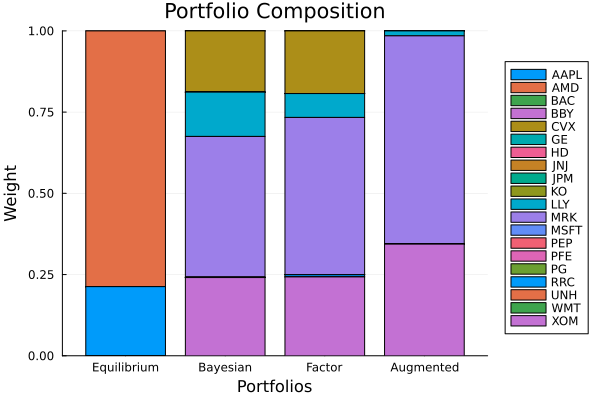

In [8]:
using Clarabel

slv = Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))
rf = 4.2 / 100 / 252

priors = ["Equilibrium" => pr_eq, "Bayesian" => pr_bayes, "Factor" => pr_fbl_rsd,
          "Augmented" => pr_aug]
res = [optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                         opt = JuMPOptimiser(; pe = p, slv = slv))) for (_, p) in priors]

pretty_table(DataFrame(hcat(rd.nx, [r.w for r in res]...),
                       [:assets; Symbol.(first.(priors))...]); formatters = [resfmt],
             title = "Maximum-ratio weights by prior")

plot_stacked_bar_composition(res, rd; xticks = (1:length(priors), first.(priors)))

## Summary

The Black–Litterman family extends well past asset-space views:

  - `BayesianBlackLittermanPrior` places factor views on a `FactorPrior`.
  - `FactorBlackLittermanPrior` propagates factor-premia views through a regression,
    with `rsd` controlling residual variance and `l` the implied equilibrium risk-aversion.
  - `AugmentedBlackLittermanPrior` blends asset views and factor views in one
    posterior.

All three return a standard asset-space posterior, so they drop into any optimiser exactly
like the base model — the difference is only in *where* the views live.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*